
## Data Visualization

Some Python libraries for data visualization:

- **Pandas** — quick .plot() directly on DataFrames
- **Matplotlib** — the foundational library everything else builds on; verbose but gives full control over every visual element.
- **Seaborn** — built on Matplotlib, allows to create good charts with less code and config.


<br>



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

superstore = pd.read_csv("../datasets/Sample - EU Superstore.csv")

superstore.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,ES-2017-1311038,07/02/2017,11/02/2017,Standard Class,AS-10045,Aaron Smayling,Corporate,Leeds,England,United Kingdom,North,OFF-ST-10000988,Office Supplies,Storage,"Fellowes Folders, Blue",79.20,3,0.0,39.6
1,2,ES-2017-1311038,07/02/2017,11/02/2017,Standard Class,AS-10045,Aaron Smayling,Corporate,Leeds,England,United Kingdom,North,TEC-AC-10004144,Technology,Accessories,"SanDisk Numeric Keypad, Bluetooth",388.92,7,0.0,0.0


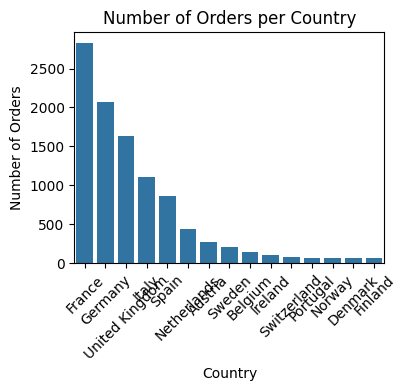

In [2]:
# render a bar chart with the number of orders per country


order_counts = superstore['Country'].value_counts()

plt.figure(figsize=(4, 3))
sns.barplot(x=order_counts.index, y=order_counts.values)
plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.title('Number of Orders per Country')
plt.xticks(rotation=45)
plt.show()


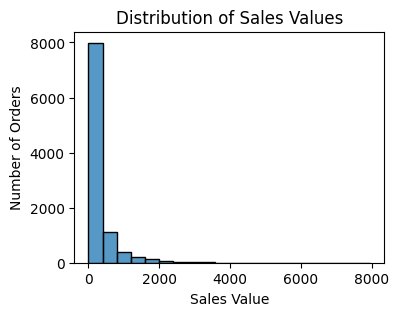

In [3]:
# render a histogram with the number of orders per sales value

plt.figure(figsize=(4, 3))
sns.histplot(superstore['Sales'], bins=20, kde=False)
plt.xlabel('Sales Value')
plt.ylabel('Number of Orders')
plt.title('Distribution of Sales Values')
plt.show()


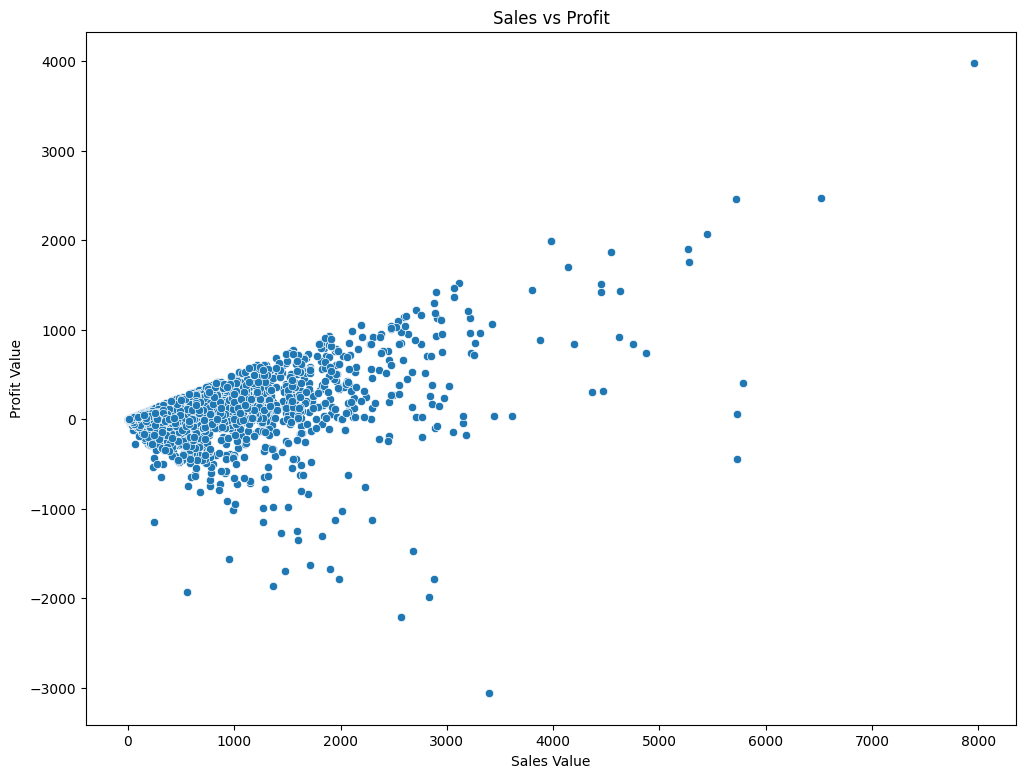

In [4]:
# render a scatter plot with sales vs profit

plt.figure(figsize=(12, 9))
sns.scatterplot(data=superstore, x='Sales', y='Profit')
plt.xlabel('Sales Value')
plt.ylabel('Profit Value')
plt.title('Sales vs Profit')
plt.show()



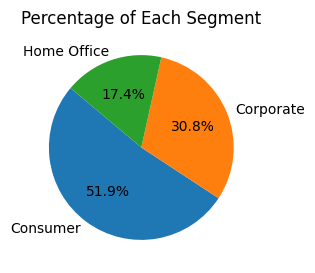

In [5]:
# render a pie chart with the percentages of each segment 

segment_counts = superstore['Segment'].value_counts()

plt.figure(figsize=(3, 3))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Percentage of Each Segment')
plt.show()

<br>
<hr>
<hr>
<br>

## Discover: Boxplots

Discover: Boxplots

Instructions:
- https://gist.github.com/luisjunco/e372a523bfa19b41031d376958ea0a46

Time: 15-20 minutes.

<br>
<hr>
<hr>
<br>




<br>

## Correlation

In [6]:
superstore[["Sales", "Profit"]].corr()

,Sales,Profit
Sales,1.000000,0.472645
Profit,0.472645,1.000000


In [7]:

# numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
# only_numerics = superstore.select_dtypes(include=numerics)

only_numerics = superstore[["Sales", "Quantity", "Discount", "Profit"]]
only_numerics.corr()

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.345116,-0.016923,0.472645
Quantity,0.345116,1.000000,0.000939,0.111326
Discount,-0.016923,0.000939,1.000000,-0.339153
Profit,0.472645,0.111326,-0.339153,1.000000


<Axes: >

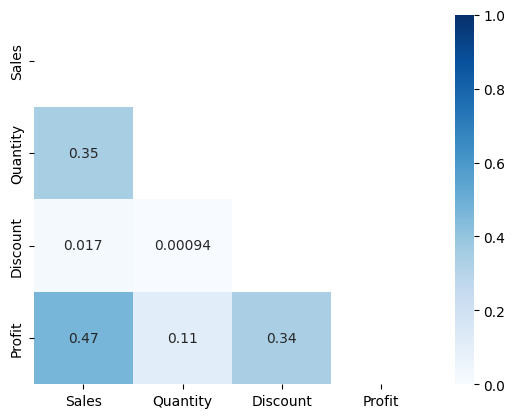

In [8]:
# render correlation heatmap (render with a mask to hide the upper triangle of the heatmap)

import numpy as np

mask = np.triu(np.ones_like(only_numerics.corr(), dtype=bool)) 

sns.heatmap(
    only_numerics.corr().abs(),
    annot=True,
    cmap="Blues",
    vmin=0, vmax=1,
    mask=mask
)

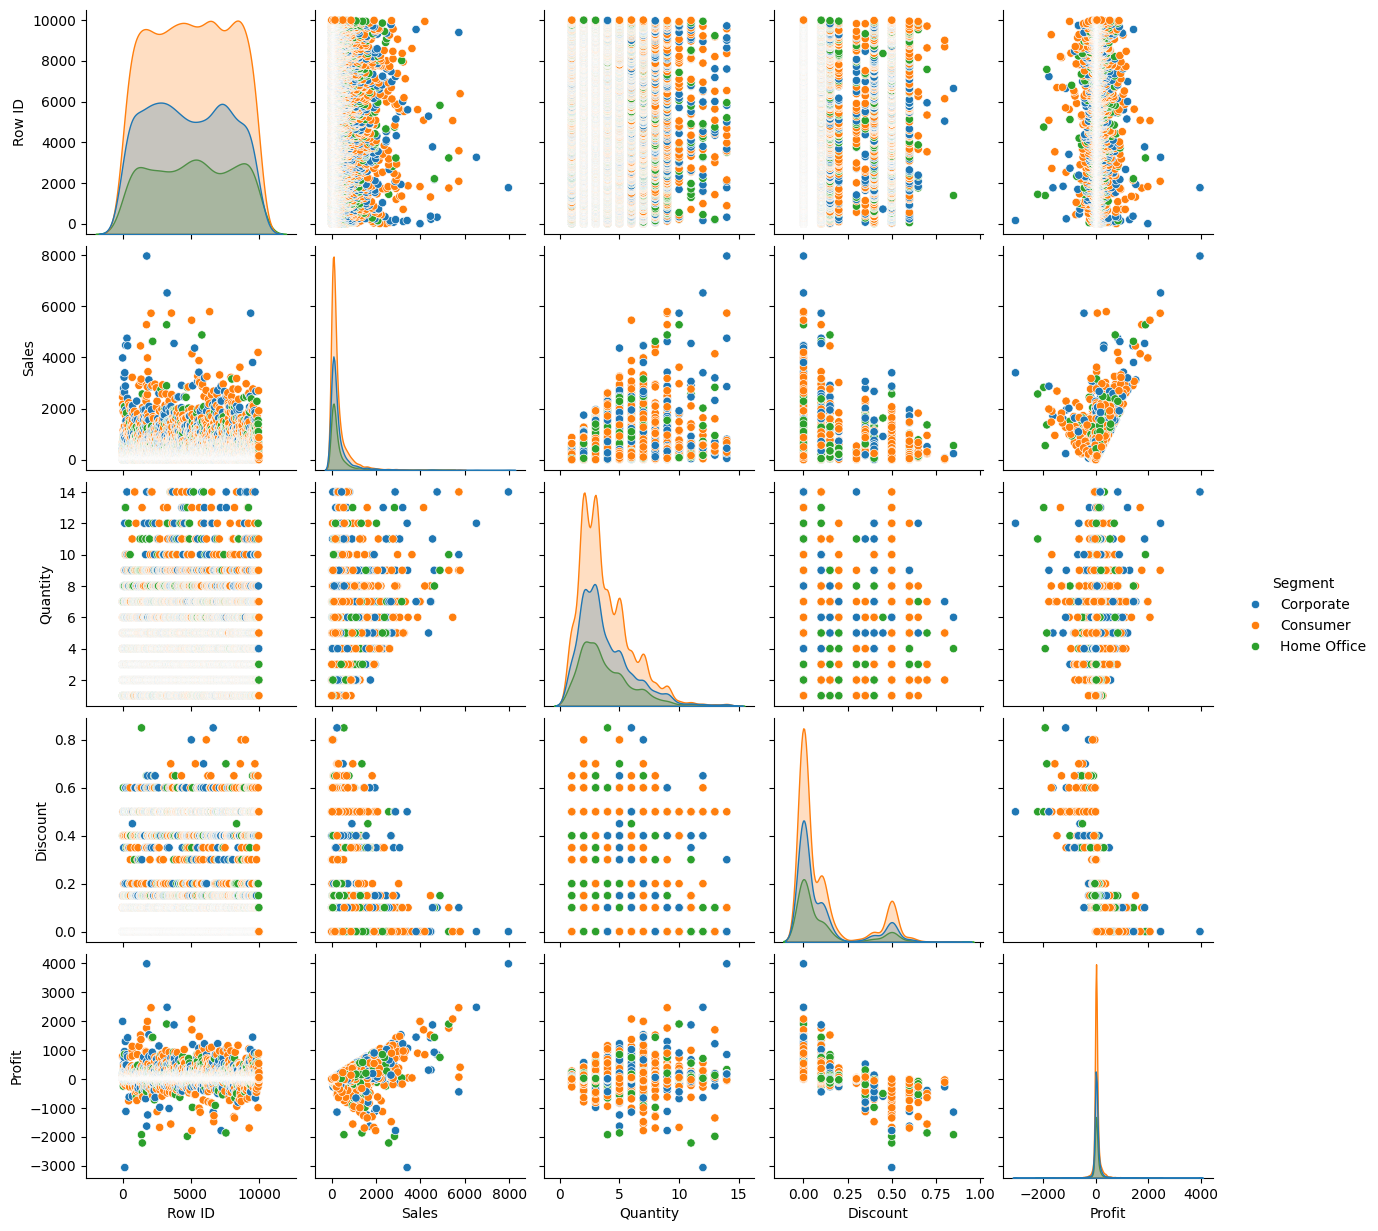

In [9]:
# finally, we couldnt end without the atomic bomb of plotting - also used in EDA

sns.pairplot(superstore, hue = 'Segment')